# 04 — Explainability

Generates per-prediction SHAP-style explanations using XGBoost's native `pred_contribs` (fast, mathematically equivalent to `shap.TreeExplainer` but practical at 54 classes), builds the interaction-type translation dictionary, and demonstrates mapping fingerprint bits back to chemistry.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import joblib
import xgboost as xgb

model = joblib.load('../models/ddi_xgb.joblib')
le = joblib.load('../models/label_encoder.joblib')
X_test = np.load('../data/X_fingerprints.npy')  # sample rows for demonstration


## Native contributions — smoke test

In [2]:
dtest_small = xgb.DMatrix(X_test[:5].astype(np.float32))
contribs_small = model.get_booster().predict(dtest_small, pred_contribs=True)
print(contribs_small.shape)


(5, 54, 4097)


## Global summary plot (sample of 500 rows)

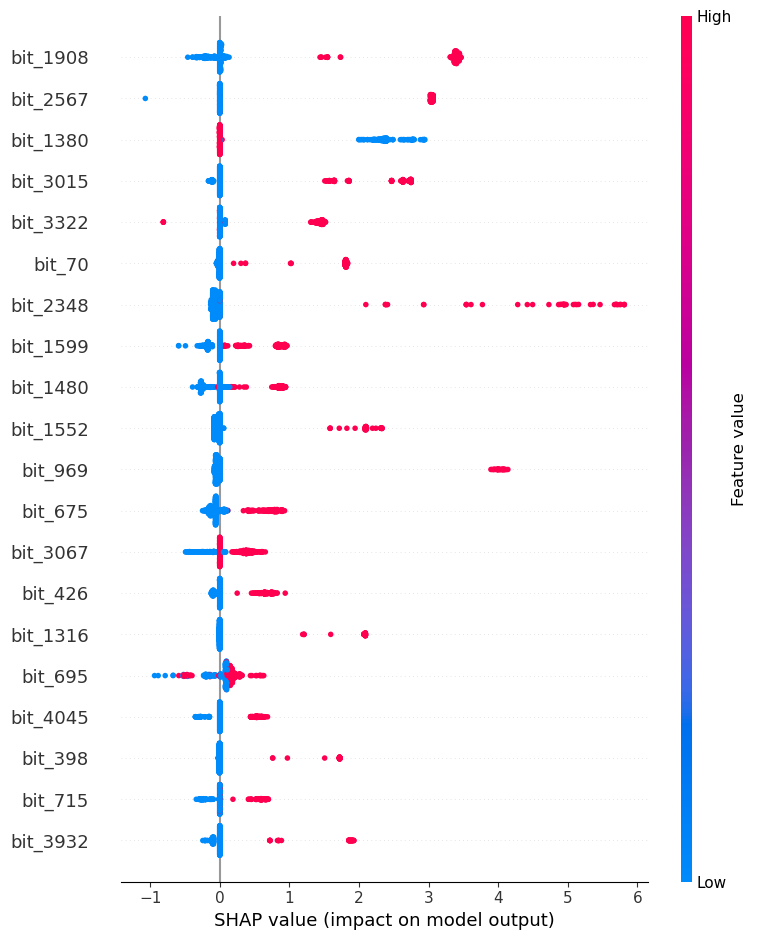

In [3]:
import matplotlib.pyplot as plt
import shap  # plotting utilities only — not used as the explainer

sample_size = 500
dtest = xgb.DMatrix(X_test[:sample_size].astype(np.float32))
contribs = model.get_booster().predict(dtest, pred_contribs=True)
y_pred_sample = model.predict(X_test[:sample_size].astype(np.float32))

idx = np.arange(sample_size)
sample_contribs = contribs[idx, y_pred_sample.astype(int), :-1]

shap.summary_plot(
    sample_contribs, X_test[:sample_size],
    feature_names=[f'bit_{i}' for i in range(X_test.shape[1])],
    show=False
)
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')


## Per-prediction explanation

In [7]:
from src.explain import explain_prediction

fp1_example = X_test[0][:2048]
fp2_example = X_test[0][2048:]

label, top_features = explain_prediction(fp1_example, fp2_example, model, le)
print(label)
print(top_features)


Other
[(3643, 0.8583579063415527), (3180, 0.38293829560279846), (3482, 0.29377150535583496), (2510, 0.17358645796775818), (3782, 0.1266033947467804), (1391, 0.11970673501491547), (314, -0.11119157075881958), (2275, 0.10793981701135635), (2855, 0.0986836850643158), (2485, 0.09783194959163666)]


## Build the interaction-type translation dictionary

Maps each class ID to its plain-English meaning (`#Drug1`/`#Drug2` placeholders get substituted with real drug names later, in `src/predict.py`). `Other` gets a dedicated explanatory note since it isn't a real pharmacological category — it's a statistical merge of 33 data-poor classes.

In [5]:
from tdc.utils import get_label_map
import json

raw_label_map = get_label_map(name='DrugBank', task='DDI', path='../data')
interaction_translations = {str(k): v for k, v in raw_label_map.items()}

interaction_translations['Other'] = (
    "This pair falls into a less common interaction category — one of 33 "
    "rarer interaction types that were grouped together during training "
    "due to limited data for each individually."
)

with open('../models/interaction_translations.json', 'w') as f:
    json.dump(interaction_translations, f, indent=2)

print(f"Saved {len(interaction_translations)} translations")


Saved 87 translations


## Map a fingerprint bit back to chemistry

Uses `bitInfo` to see which atom/substructure generated a given bit — the connective tissue between a SHAP-flagged feature and an actual chemical explanation. Swap in a top feature index from `explain_prediction`'s output above to trace a real prediction, rather than an arbitrary molecule.

In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem

info = {}
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')  # aspirin
fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048, bitInfo=info)
print(info)


{389: ((12, 1),), 456: ((10, 1),), 650: ((2, 0), (11, 0)), 695: ((3, 0),), 807: ((1, 0), (10, 0), (12, 0)), 909: ((4, 2),), 1017: ((0, 1),), 1035: ((1, 1),), 1047: ((10, 2),), 1057: ((0, 0),), 1088: ((6, 1), (7, 1)), 1199: ((6, 2), (7, 2)), 1380: ((4, 0), (9, 0)), 1410: ((5, 2),), 1447: ((8, 2),), 1468: ((3, 2),), 1616: ((9, 2),), 1729: ((3, 1),), 1750: ((5, 1), (8, 1)), 1775: ((1, 2),), 1873: ((5, 0), (6, 0), (7, 0), (8, 0)), 1917: ((2, 1), (11, 1)), 1970: ((4, 1),), 1991: ((9, 1),)}
